In [1]:
# Import required libraries for data handling, ML, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ML models and tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [2]:
# Load dataset with robust settings to handle malformed rows
df = pd.read_csv(
    "data.csv",
    engine="python",        # flexible parser for messy CSV
    on_bad_lines="skip",    # skip corrupted rows
    encoding="latin-1"      # handle special characters
)

# Rename columns to standard format
df.columns = ["password", "strength"]

# Remove rows with missing passwords
df = df.dropna(subset=["password"])

# Convert passwords to string (ensures no float errors)
df["password"] = df["password"].astype(str)

# Keep only valid strength labels
df = df[df["strength"].isin([0, 1, 2])]

# Reset index after cleaning
df = df.reset_index(drop=True)

# Display dataset info
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (669639, 2)


,password,strength
0,kzde5577,1
1,kino3434,1
2,visi7k1yr,1
3,megzy123,1
4,lamborghin1,1


strength
1    496801
0     89701
2     83137
Name: count, dtype: int64


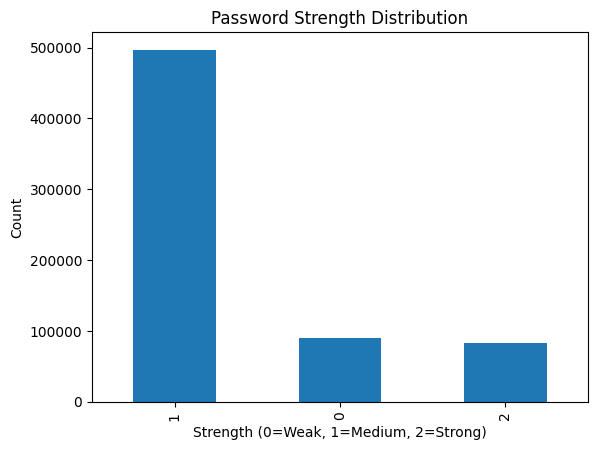

In [3]:
# Check class distribution to understand balance
print(df["strength"].value_counts())

# Visualize class distribution
df["strength"].value_counts().plot(kind='bar')
plt.title("Password Strength Distribution")
plt.xlabel("Strength (0=Weak, 1=Medium, 2=Strong)")
plt.ylabel("Count")
plt.show()

In [4]:
# Extract numerical features from passwords for ML model

def extract_features(password):
    length = len(password)

    digits = sum(c.isdigit() for c in password)
    lower = sum(c.islower() for c in password)
    upper = sum(c.isupper() for c in password)
    special = sum(not c.isalnum() for c in password)

    # Entropy calculation (randomness of password)
    prob = [password.count(c)/len(password) for c in set(password)]
    entropy = -sum([p * np.log2(p) for p in prob])

    # Check repeated characters
    repeated = sum(password.count(c) > 1 for c in set(password))

    # Sequential pattern detection
    patterns = ["123", "abc", "qwerty"]
    pattern_flag = int(any(p in password.lower() for p in patterns))

    return [length, digits, lower, upper, special, entropy, repeated, pattern_flag]

In [5]:
# Apply feature extraction to all passwords
X = df["password"].apply(extract_features).tolist()

# Target variable (strength)
y = df["strength"]

In [6]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# Initialize models
rf = RandomForestClassifier(n_estimators=100)
lr = LogisticRegression(max_iter=1000)
svm = SVC()

# Train models
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [8]:
# Predict using all models
rf_pred = rf.predict(X_test)
lr_pred = lr.predict(X_test)
svm_pred = svm.predict(X_test)

# Print accuracy for comparison
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

# Choose best model (Random Forest generally performs best)
model = rf

# Detailed evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9998954662206558
Logistic Regression Accuracy: 0.9998431993309839
SVM Accuracy: 0.9998954662206558

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17908
           1       1.00      1.00      1.00     99519
           2       1.00      1.00      1.00     16501

    accuracy                           1.00    133928
   macro avg       1.00      1.00      1.00    133928
weighted avg       1.00      1.00      1.00    133928



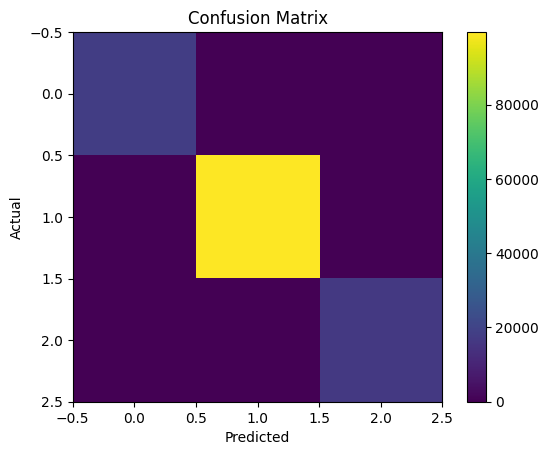

In [9]:
# Generate confusion matrix to analyze prediction errors
cm = confusion_matrix(y_test, rf_pred)

# Plot confusion matrix
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [10]:
# Common password list (simulating dictionary attack)
common_passwords = ["123456", "password", "qwerty", "abc123"]

# Check if password is common
def is_common(password):
    return password.lower() in common_passwords

# Estimate brute-force crack time
def estimate_crack_time(password):
    charset = 0

    if any(c.islower() for c in password): charset += 26
    if any(c.isupper() for c in password): charset += 26
    if any(c.isdigit() for c in password): charset += 10
    if any(not c.isalnum() for c in password): charset += 32

    combinations = charset ** len(password)
    guesses_per_sec = 1e9  # 1 billion guesses/sec

    seconds = combinations / guesses_per_sec
    return seconds

In [11]:
# Predict password strength with detailed analysis

def predict_strength(password):
    features = extract_features(password)
    prediction = model.predict([features])[0]

    print("\n🔍 Password Analysis Report")

    if prediction == 0:
        print("Strength: Weak ❌")
    elif prediction == 1:
        print("Strength: Medium ⚠️")
    else:
        print("Strength: Strong ✅")

    # Crack time estimation
    time = estimate_crack_time(password)
    print(f"Estimated Crack Time: {time:.2f} seconds")

    # Security warnings
    if is_common(password):
        print("⚠️ Common password detected (dictionary attack risk)")

    if any(p in password.lower() for p in ["123", "abc", "qwerty"]):
        print("⚠️ Pattern detected (easy to guess)")

    if len(password) < 8:
        print("⚠️ Password too short")

In [12]:
# Single user input
pwd = input("Enter a password: ")
predict_strength(pwd)


🔍 Password Analysis Report
Strength: Strong ✅
Estimated Crack Time: 441806122887085979132938116577328365568.00 seconds


In [13]:
# Continuous loop for multiple inputs
while True:
    pwd = input("\nEnter password (type 'exit' to stop): ")

    if pwd.lower() == "exit":
        print("Exited.")
        break

    predict_strength(pwd)


🔍 Password Analysis Report
Strength: Strong ✅
Estimated Crack Time: 441806122887085979132938116577328365568.00 seconds
Exited.
